# Détection Automatique de Pathologies
### Classification Binaire sur SynMedTab-800

#### Objectif
Construire et comparer plusieurs modèles de classification binaire pour prédire la présence ou l'absence d'une pathologie à partir de données cliniques tabulaires synthétiques.

#### Dataset : SynMedTab-800
- Données synthétiques représentant 800 patients
- Variables quantitatives : âge, pression artérielle, cholestérol, glycémie, IMC
- Variables catégorielles : statut tabagique, niveau d'activité, antécédents familiaux, qualité alimentation
- Cible binaire : présence (1) ou absence (0) de pathologie

#### Méthodologie
Suivre le pipeline ML complet depuis l'exploration jusqu'à l'analyse critique des résultats, en progressant du modèle simple au plus complexe.

## 1. IMPORTS ET CONFIGURATION
Assure que toutes les bibliothèques nécessaires sont importées et configure l'environnement de travail.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (confusion_matrix, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, auc,
                             classification_report, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Tous les imports réussis")

✓ Tous les imports réussis


### 1.1 Reproductibilité et état du kernel

Pour garantir un contexte strictement reproductible:
- redémarrer le kernel puis exécuter tout le notebook (Run All),
- fixer la graine aléatoire,
- supprimer les variables issues d'expérimentations hors flux principal (ex: SMOTE, GridSearchCV).

In [2]:
import random

SEED = 42
RANDOM_STATE = SEED
np.random.seed(SEED)
random.seed(SEED)

# Nettoyage des objets souvent laissés par des essais hors notebook principal
stale_symbols = [
    'SMOTE', 'smote',
    'GridSearchCV', 'grid_search', 'param_grid_rf',
    'X_train_smote', 'y_train_smote',
    'model_lr_smote', 'model_dt_smote', 'model_rf_smote',
    'results_lr_smote', 'results_dt_smote', 'results_rf_smote',
    'model_rf_optimized', 'results_rf_optimized',
    'cv_scores', 'cv_scores_lr', 'cv_scores_dt', 'cv_scores_rf',
    'cv_results_all', 'cv_summary_df', 'models_cv',
    'models_to_calibrate', 'models_to_calibrate_adv'
 ]

removed_symbols = [name for name in stale_symbols if name in globals()]
for name in removed_symbols:
    del globals()[name]

print(f"✓ Seed fixée à {SEED}")
print(f"✓ Variables hors flux supprimées: {len(removed_symbols)}")
if removed_symbols:
    print('  ->', ', '.join(removed_symbols))

✓ Seed fixée à 42
✓ Variables hors flux supprimées: 0


## 2. CHARGEMENT DES DONNÉES
Utilise la fonction 'load_data()' pour charger le dataset SynMedTab-800. Affiche les premières lignes du dataframe pour vérifier le chargement correct des données.

In [3]:
df = pd.read_csv('SynMedTab-800.csv')

print("Aperçu du dataset:")
print(df.head())
print(f"\nDimensions: {df.shape}")
print(f"\nTypes de données:")
print(df.dtypes)
print(f"\nValeurs manquantes avant transformation:")
print(df.isnull().sum())

Aperçu du dataset:
   patient_id   age  blood_pressure_mmhg  cholesterol_mgdl  glucose_mgdl  \
0           1  68.7                125.6             193.9           NaN   
1           2  64.3                132.5             173.4          75.2   
2           3  51.1                118.3             213.3          86.4   
3           4   NaN                146.7             193.7          82.9   
4           5  47.5                144.3             182.6         182.6   

    bmi smoking_status physical_activity family_history diet_quality disease  
0  29.5          Never          Moderate             No    Excellent      No  
1  24.5          Never          Moderate             No         Fair      No  
2  26.2         Former              High            NaN         Good      No  
3  27.8          Never               NaN             No          NaN      No  
4  31.6          Never               Low            Yes         Poor     Yes  

Dimensions: (800, 11)

Types de données:
patient_

---
## 3. EXPLORATION ET ANALYSE EXPLORATOIRE (EDA)

### 3.1 Distribution de la variable cible
Visualise la distribution de la variable cible (présence/absence de pathologie) pour évaluer l'équilibre des classes.

Distribution de la variable cible (disease):
disease
No     614
Yes    186
Name: count, dtype: int64

Proportion:
disease
No     0.7675
Yes    0.2325
Name: proportion, dtype: float64


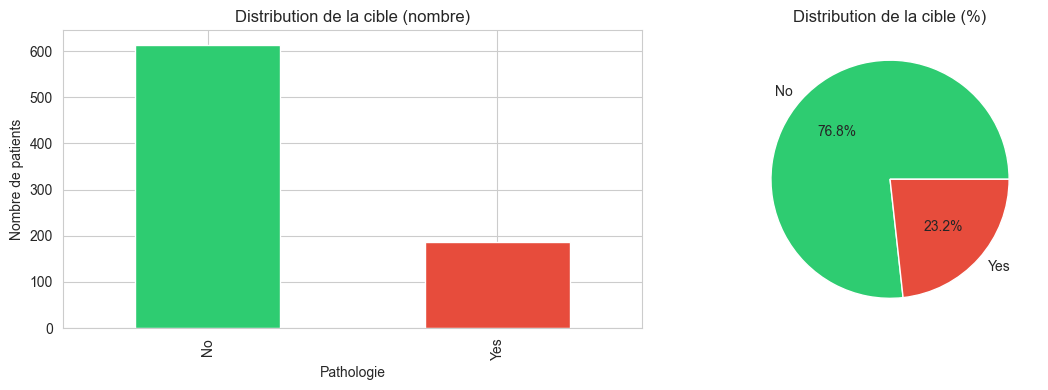


Cible convertie: No=0, Yes=1
Imbalancement des classes: 76.8%


In [4]:
target_col = 'disease'

print(f"Distribution de la variable cible ({target_col}):")
print(df[target_col].value_counts())
print(f"\nProportion:")
print(df[target_col].value_counts(normalize=True))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df[target_col].value_counts().plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Distribution de la cible (nombre)')
ax[0].set_ylabel('Nombre de patients')
ax[0].set_xlabel('Pathologie')

df[target_col].value_counts(normalize=True).plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
                                                   colors=['#2ecc71', '#e74c3c'])
ax[1].set_title('Distribution de la cible (%)')
plt.tight_layout()
plt.show()

# Convertir 'No'/'Yes' en 0/1
df[target_col] = (df[target_col] == 'Yes').astype(int)
print(f"\nCible convertie: No=0, Yes=1")
imbalance = abs(100 - df[target_col].value_counts(normalize=True)[1]*100)
print(f"Imbalancement des classes: {imbalance:.1f}%")

### 3.2 Identification des variables

In [5]:
numerical_cols = ['age', 'blood_pressure_mmhg', 'cholesterol_mgdl', 'glucose_mgdl', 'bmi']
categorical_cols = ['smoking_status', 'physical_activity', 'family_history', 'diet_quality']

print(f"Variables quantitatives ({len(numerical_cols)}):")
print(numerical_cols)
print(f"\nVariables catégorielles ({len(categorical_cols)}):")
print(categorical_cols)

print(f"\nStatistiques descriptives des variables quantitatives:")
print(df[numerical_cols].describe())

Variables quantitatives (5):
['age', 'blood_pressure_mmhg', 'cholesterol_mgdl', 'glucose_mgdl', 'bmi']

Variables catégorielles (4):
['smoking_status', 'physical_activity', 'family_history', 'diet_quality']

Statistiques descriptives des variables quantitatives:
              age  blood_pressure_mmhg  cholesterol_mgdl  glucose_mgdl  \
count  716.000000           730.000000        721.000000    704.000000   
mean    51.353911           126.327397        209.344105    107.010085   
std     13.256483            19.297168         37.638613     29.352447   
min     18.000000            78.800000        105.400000     50.000000   
25%     43.075000           113.600000        185.900000     88.300000   
50%     51.600000           124.800000        206.000000    101.250000   
75%     60.050000           137.850000        232.000000    119.850000   
max     89.700000           199.400000        335.800000    243.100000   

              bmi  
count  733.000000  
mean    26.539291  
std      4

### 3.3 Analyse des anomalies et valeurs manquantes
Trouve et affiche les anomalies et les valeurs manquantes dans le dataset. 

Zéros par colonne numérique:

Valeurs manquantes par colonne:
age                    84
blood_pressure_mmhg    70
cholesterol_mgdl       79
glucose_mgdl           96
bmi                    67
smoking_status         69
physical_activity      90
family_history         83
diet_quality           88
dtype: int64


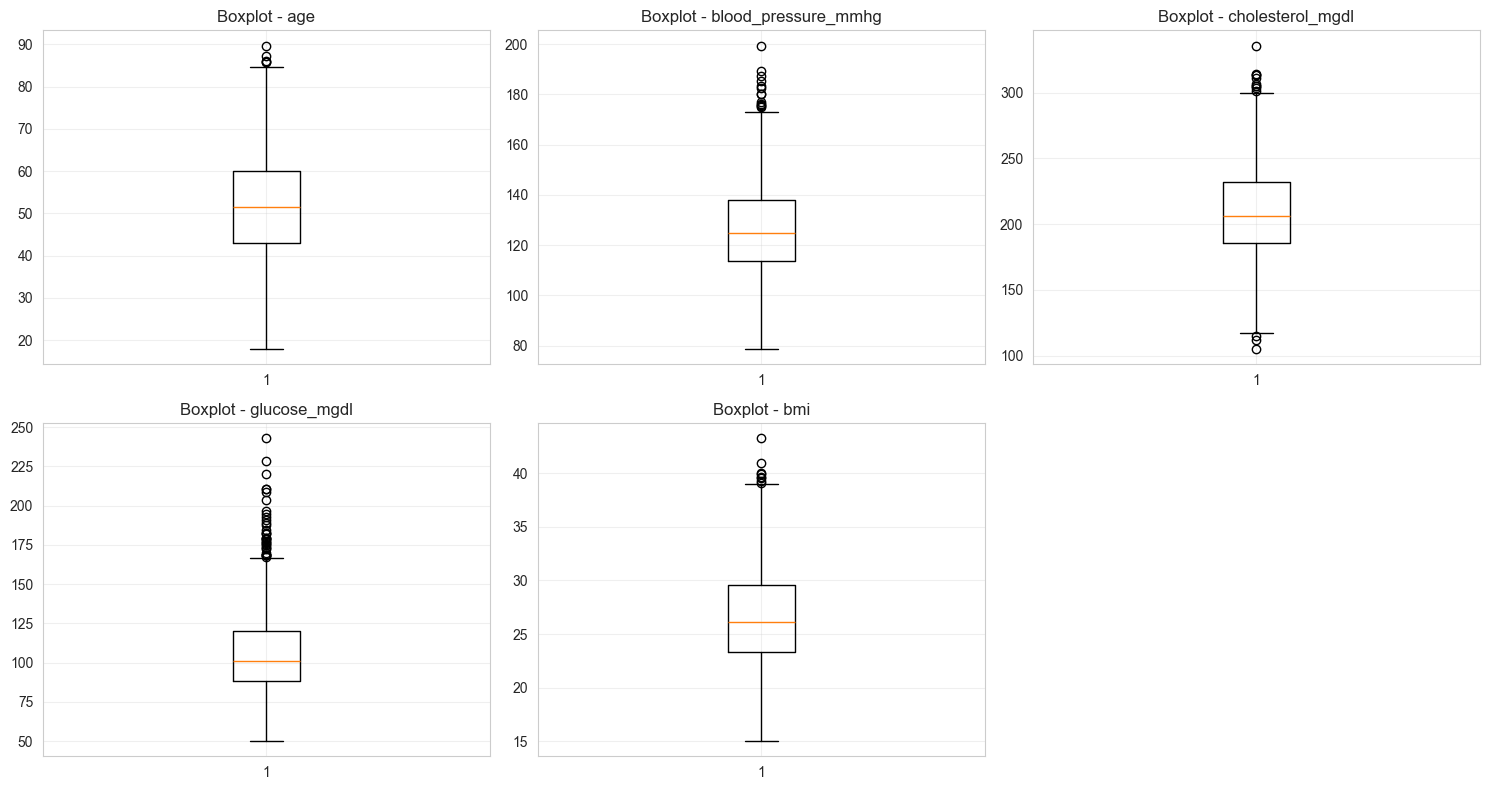


✓ Anomalies détectées: zéros biologiquement impossibles, valeurs manquantes


In [6]:
print("Zéros par colonne numérique:")
for col in numerical_cols:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f"  {col}: {zero_count} zéros ({zero_count/len(df)*100:.1f}%)")

print("\nValeurs manquantes par colonne:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Visualisation des anomalies
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'Boxplot - {col}')
    axes[idx].grid(True, alpha=0.3)

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

print("\n✓ Anomalies détectées: zéros biologiquement impossibles, valeurs manquantes")

### 3.4 Corrélations avec la cible
Creation d'une matrice de corrélation pour identfier quelles variables sont les plus corrélées avec la variable cible.

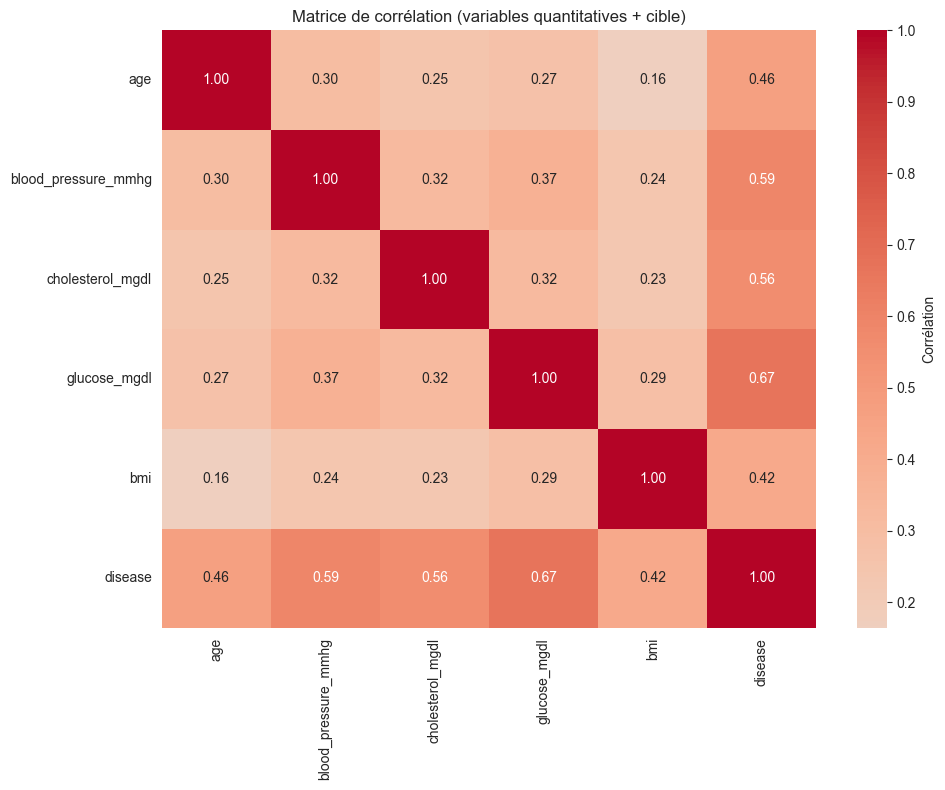


Corrélations avec la cible (disease):
disease                1.000000
glucose_mgdl           0.666476
blood_pressure_mmhg    0.586087
cholesterol_mgdl       0.556106
age                    0.463024
bmi                    0.419289
Name: disease, dtype: float64


In [7]:
data_for_corr = df[numerical_cols + [target_col]].copy()
corr_matrix = data_for_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Corrélation'})
plt.title('Matrice de corrélation (variables quantitatives + cible)')
plt.tight_layout()
plt.show()

print(f"\nCorrélations avec la cible ({target_col}):")
target_corr = corr_matrix[target_col].sort_values(ascending=False)
print(target_corr)

---
## 4. PRÉPARATION ET NETTOYAGE DES DONNÉES
Le but ici est de préparer les données pour l'entraînement des modèles, en traitant les valeurs manquantes, les variables catégorielles et en effectuant une sélection de caractéristiques.

### 4.1 Séparation features / target
Selection des features et du target à partir du dataframe.

In [8]:
X = df.drop(columns=[target_col, 'patient_id'])
y = df[target_col]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nColonnes de X: {X.columns.tolist()}")

X shape: (800, 9)
y shape: (800,)

Colonnes de X: ['age', 'blood_pressure_mmhg', 'cholesterol_mgdl', 'glucose_mgdl', 'bmi', 'smoking_status', 'physical_activity', 'family_history', 'diet_quality']


### 4.2 Gestion des valeurs manquantes et anomalies
Localise et traite les valeurs manquantes et aplique des méthodes de nettoyage pour les anomalies identifiées.

In [9]:
X_clean = X.copy()

# Colonnes où 0 est considéré comme biologiquement impossible
cols_zero_anomaly = ['blood_pressure_mmhg', 'cholesterol_mgdl', 'glucose_mgdl', 'bmi']

print("Remplacement direct des zéros par la médiane de chaque colonne:")
for col in cols_zero_anomaly:
    median_col = X_clean.loc[X_clean[col] != 0, col].median()
    zero_count = (X_clean[col] == 0).sum()
    X_clean.loc[X_clean[col] == 0, col] = median_col
    print(f"  ✓ {col}: {zero_count} zéros remplacés par médiane = {median_col:.2f}")

print("\nValeurs manquantes avant remplissage final:")
print(X_clean.isnull().sum())

# Sécurisation: si des NaN existent encore, on les remplit avec la médiane
for col in numerical_cols:
    X_clean[col] = X_clean[col].fillna(X_clean[col].median())

print("\nAprès remplacement (médianes) :")
print(X_clean.isnull().sum())
print("✓ Données numériques nettoyées avec la stratégie médiane (sans passer par NaN pour les zéros)")

Remplacement direct des zéros par la médiane de chaque colonne:
  ✓ blood_pressure_mmhg: 0 zéros remplacés par médiane = 124.80
  ✓ cholesterol_mgdl: 0 zéros remplacés par médiane = 206.00
  ✓ glucose_mgdl: 0 zéros remplacés par médiane = 101.25
  ✓ bmi: 0 zéros remplacés par médiane = 26.10

Valeurs manquantes avant remplissage final:
age                    84
blood_pressure_mmhg    70
cholesterol_mgdl       79
glucose_mgdl           96
bmi                    67
smoking_status         69
physical_activity      90
family_history         83
diet_quality           88
dtype: int64

Après remplacement (médianes) :
age                     0
blood_pressure_mmhg     0
cholesterol_mgdl        0
glucose_mgdl            0
bmi                     0
smoking_status         69
physical_activity      90
family_history         83
diet_quality           88
dtype: int64
✓ Données numériques nettoyées avec la stratégie médiane (sans passer par NaN pour les zéros)


### 4.3 Train / Test Split (AVANT normalisation)
Creation des ensembles d'entraînement et de test grâce aux données traitées juste avant.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, 
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"\nDistribution train:")
print(y_train.value_counts(normalize=True))
print(f"\nDistribution test:")
print(y_test.value_counts(normalize=True))
print("✓ Stratification conservée")

X_train: (640, 9)
X_test: (160, 9)

Distribution train:
disease
0    0.767188
1    0.232813
Name: proportion, dtype: float64

Distribution test:
disease
0    0.76875
1    0.23125
Name: proportion, dtype: float64
✓ Stratification conservée


### 4.4 Prétraitement : Normalisation + Encodage
Préparation des données pour les modèles ML, en normalisant les variables quantitatives et en encodant les variables catégorielles.

In [11]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"X_train_transformed shape: {X_train_transformed.shape}")
print(f"X_test_transformed shape: {X_test_transformed.shape}")
print("✓ Normalisation et encodage complétés")

X_train_transformed shape: (640, 17)
X_test_transformed shape: (160, 17)
✓ Normalisation et encodage complétés


---
## 5. MODÉLISATION - ENTRAÎNEMENT ET ÉVALUATION
Création et évaluation de plusieurs modèles dans l'optique de les comparer et d'analyser leurs performances.

### 5.1 Fonction d'évaluation
Création d'une fonction d'évaluation commune pour tout les modèles pour permettre une comparaison cohérente des performances.

In [12]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_pred_proba = model.predict_proba(X_test)[:, 1]
    
    train_accuracy = (y_train_pred == y_train).mean()
    test_accuracy = (y_test_pred == y_test).mean()
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    auc_roc = roc_auc_score(y_test, y_test_pred_proba)
    
    print(f"\n{'='*60}")
    print(f"MODÈLE: {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy train: {train_accuracy:.4f}")
    print(f"Accuracy test:  {test_accuracy:.4f}")
    print(f"Surapprentissage: {abs(train_accuracy - test_accuracy):.4f}")
    print(f"\nMatrice de confusion (test):")
    cm = confusion_matrix(y_test, y_test_pred)
    print(cm)
    print(f"  TP: {cm[1,1]}, TN: {cm[0,0]}, FP: {cm[0,1]}, FN: {cm[1,0]}")
    print(f"\nPrécision: {precision:.4f}")
    print(f"Rappel:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc_roc:.4f}")
    
    return {
        'Model': model_name,
        'Train_Accuracy': train_accuracy,
        'Test_Accuracy': test_accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'AUC_ROC': auc_roc,
        'Overfit_Gap': abs(train_accuracy - test_accuracy),
        'y_test_pred': y_test_pred,
        'y_test_pred_proba': y_test_pred_proba,
        'model': model
    }

### 5.2 Modèle 1 : Régression Logistique
Utilisation de la régression logistique comme modèle de base pour établir une référence de performance.

In [13]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_transformed, y_train)

results_lr = evaluate_model(model_lr, X_train_transformed, X_test_transformed, 
                              y_train, y_test, "Régression Logistique")


MODÈLE: Régression Logistique
Accuracy train: 0.9781
Accuracy test:  0.9500
Surapprentissage: 0.0281

Matrice de confusion (test):
[[117   6]
 [  2  35]]
  TP: 35, TN: 117, FP: 6, FN: 2

Précision: 0.8537
Rappel:    0.9459
F1-score:  0.8974
AUC-ROC:   0.9800


### 5.3 Modèle 2 : Arbre de Décision
Implémentation d'un arbre de décision pour capturer les relations non linéaires entre les variables.

In [14]:
model_dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
model_dt.fit(X_train_transformed, y_train)

results_dt = evaluate_model(model_dt, X_train_transformed, X_test_transformed,
                             y_train, y_test, "Arbre de Décision")

print(f"\nImportance des features (Top 10):")
feature_importance = pd.DataFrame({
    'feature': range(X_train_transformed.shape[1]),
    'importance': model_dt.feature_importances_
}).sort_values('importance', ascending=False).head(10)
print(feature_importance)


MODÈLE: Arbre de Décision
Accuracy train: 0.9563
Accuracy test:  0.8875
Surapprentissage: 0.0688

Matrice de confusion (test):
[[114   9]
 [  9  28]]
  TP: 28, TN: 114, FP: 9, FN: 9

Précision: 0.7568
Rappel:    0.7568
F1-score:  0.7568
AUC-ROC:   0.9107

Importance des features (Top 10):
    feature  importance
3         3    0.571921
2         2    0.183988
1         1    0.178896
0         0    0.040222
15       15    0.011478
6         6    0.008723
4         4    0.003068
8         8    0.001704
5         5    0.000000
7         7    0.000000


### 5.4 Modèle 3 : Forêt Aléatoire
Utilisation d'une forêt aléatoire pour améliorer la performance en combinant plusieurs arbres de décision.

In [15]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)
model_rf.fit(X_train_transformed, y_train)

results_rf = evaluate_model(model_rf, X_train_transformed, X_test_transformed,
                             y_train, y_test, "Forêt Aléatoire")

print(f"\nImportance des features (Top 10):")
feature_importance_rf = pd.DataFrame({
    'feature': range(X_train_transformed.shape[1]),
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False).head(10)
print(feature_importance_rf)


MODÈLE: Forêt Aléatoire
Accuracy train: 0.9812
Accuracy test:  0.9125
Surapprentissage: 0.0687

Matrice de confusion (test):
[[113  10]
 [  4  33]]
  TP: 33, TN: 113, FP: 10, FN: 4

Précision: 0.7674
Rappel:    0.8919
F1-score:  0.8250
AUC-ROC:   0.9692

Importance des features (Top 10):
    feature  importance
1         1    0.274073
3         3    0.244235
2         2    0.196307
0         0    0.118267
4         4    0.079299
8         8    0.027831
11       11    0.021295
6         6    0.016209
15       15    0.005930
14       14    0.004935


### 5.5 Modèle 4 : K plus proches voisins (KNN)

Implémentation d'un modèle KNN pour évaluer la performance d'une approche basée sur la proximité des données.

In [16]:
model_knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='minkowski',
    p=2
)
model_knn.fit(X_train_transformed, y_train)

results_knn = evaluate_model(
    model_knn,
    X_train_transformed,
    X_test_transformed,
    y_train,
    y_test,
    "KNN"
)


MODÈLE: KNN
Accuracy train: 1.0000
Accuracy test:  0.9375
Surapprentissage: 0.0625

Matrice de confusion (test):
[[120   3]
 [  7  30]]
  TP: 30, TN: 120, FP: 3, FN: 7

Précision: 0.9091
Rappel:    0.8108
F1-score:  0.8571
AUC-ROC:   0.9567


### 5.6 Modèle 5 : Réseau de Neurones (MLP)

Utilisation d'un reseau de neurones multi-couches pour capturer des relations complexes entre les variables.

In [17]:
model_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=500,
    random_state=42
)
model_mlp.fit(X_train_transformed, y_train)

results_mlp = evaluate_model(
    model_mlp,
    X_train_transformed,
    X_test_transformed,
    y_train,
    y_test,
    "Réseau de Neurones (MLP)"
)


MODÈLE: Réseau de Neurones (MLP)
Accuracy train: 1.0000
Accuracy test:  0.9250
Surapprentissage: 0.0750

Matrice de confusion (test):
[[116   7]
 [  5  32]]
  TP: 32, TN: 116, FP: 7, FN: 5

Précision: 0.8205
Rappel:    0.8649
F1-score:  0.8421
AUC-ROC:   0.9809


### 5.7 Représentations Graphiques des Modèles

Cette section regroupe des graphes faciles à commenter pour chaque modèle :
- Matrice de confusion normalisée
- Courbe ROC
- Distribution des probabilités prédites

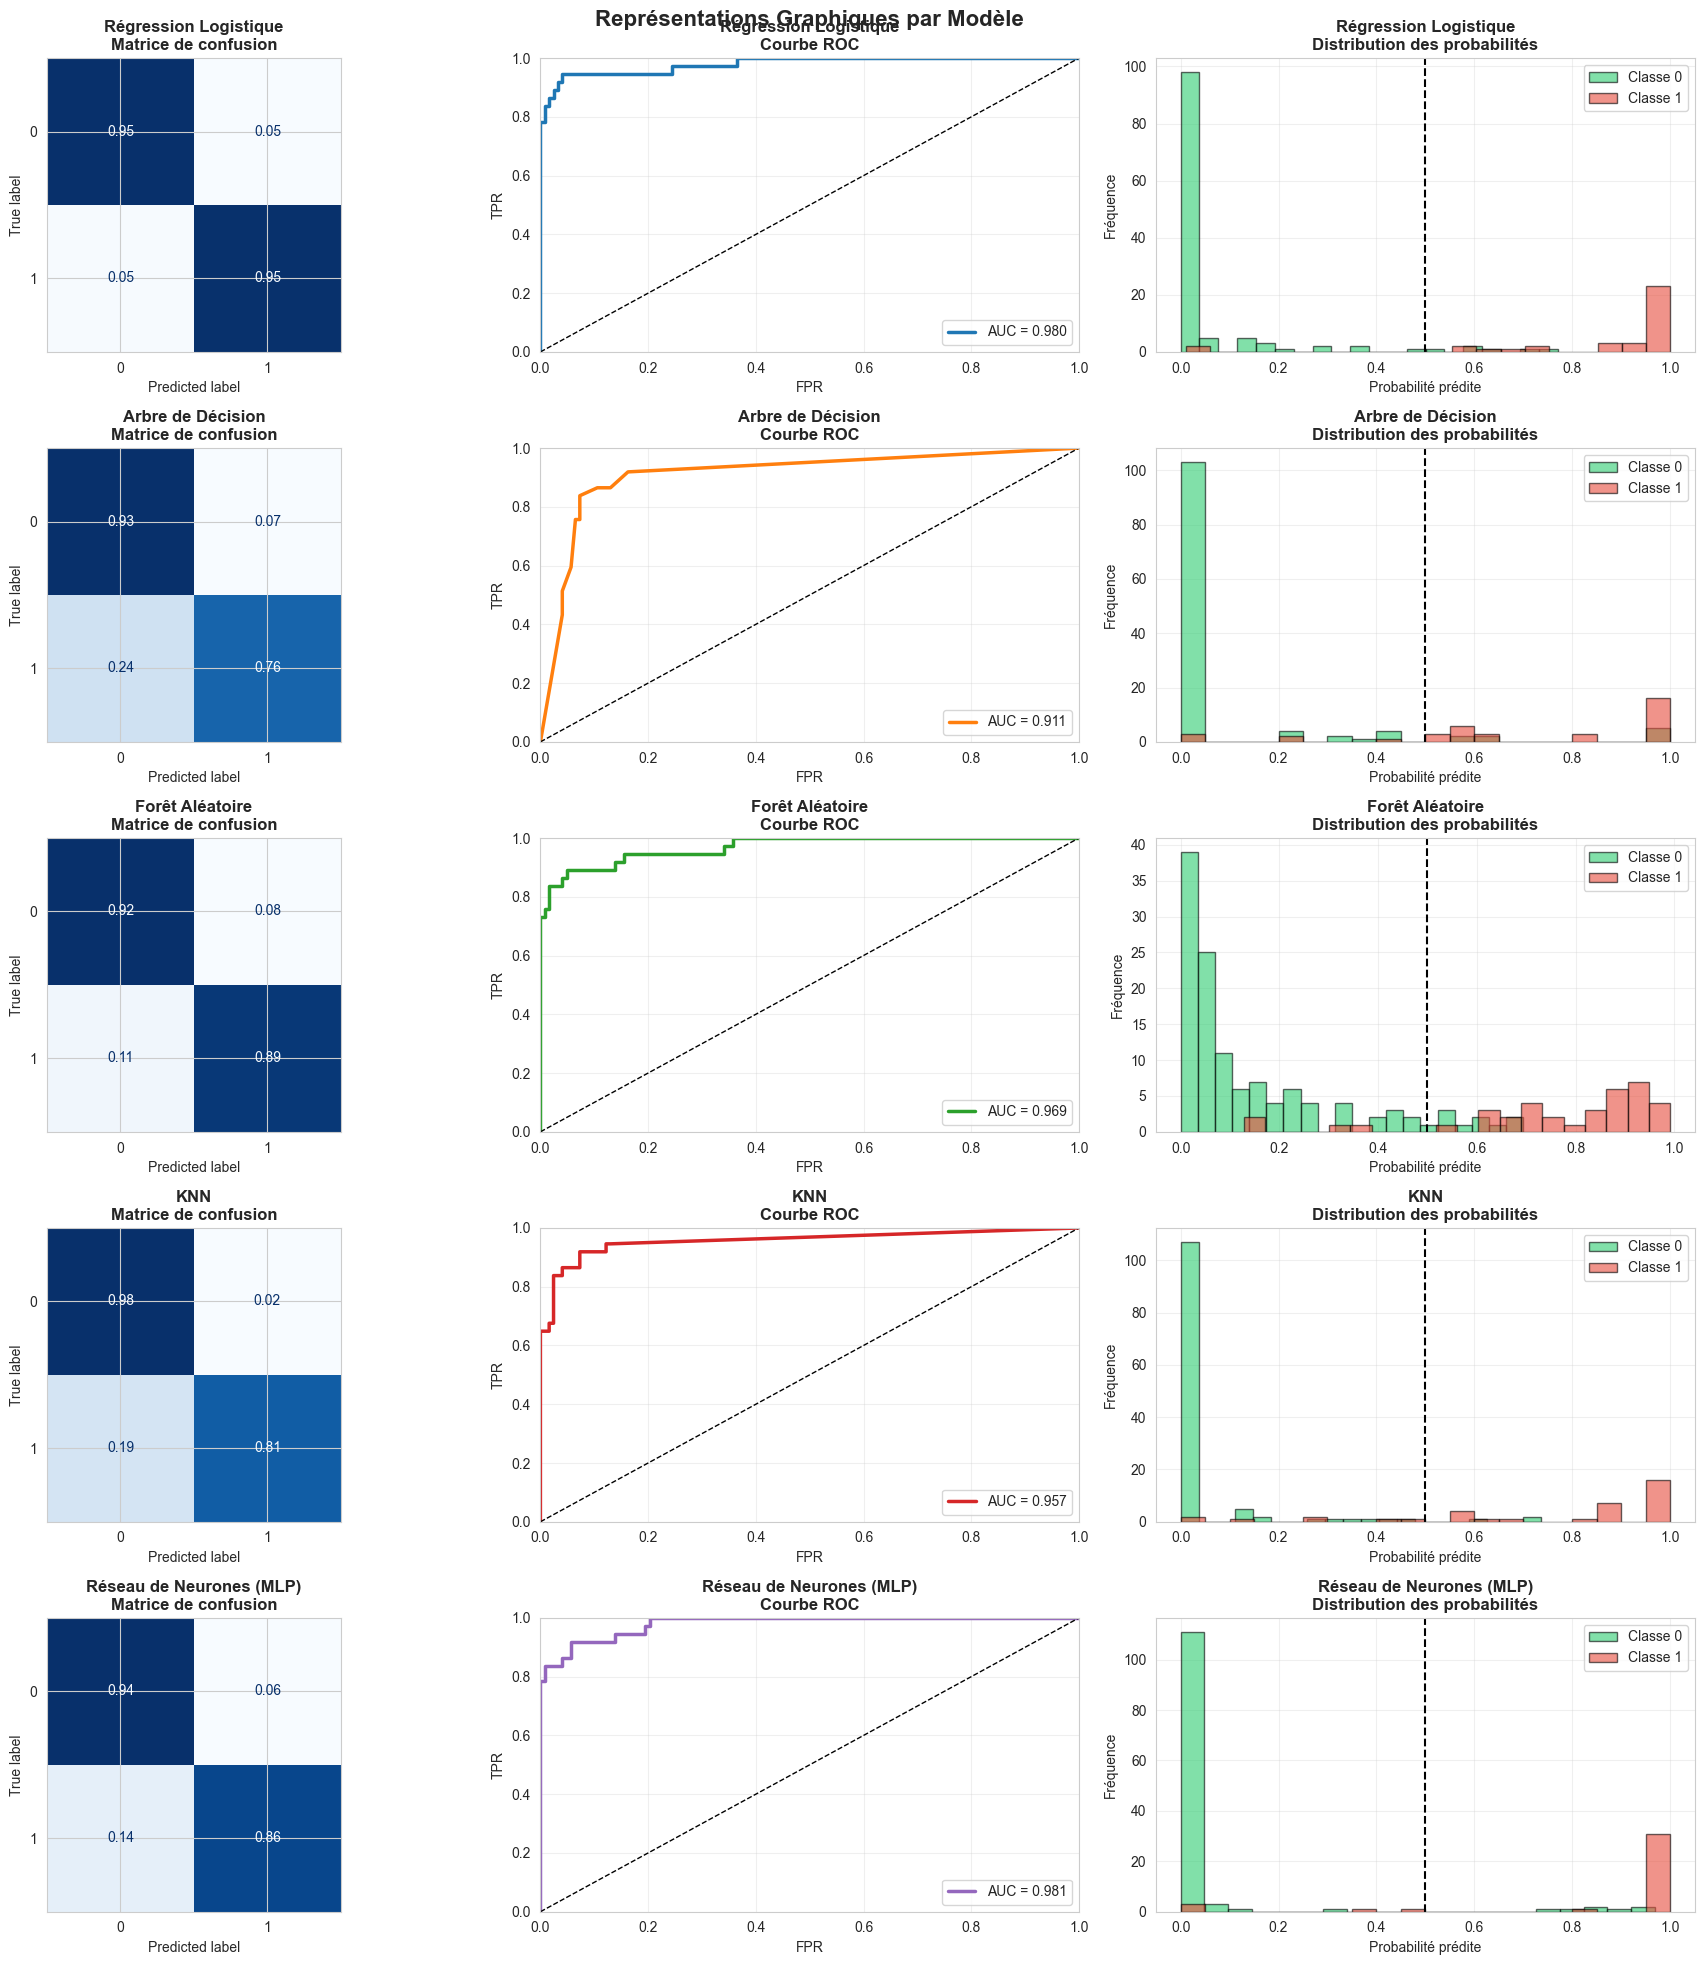


Guide de commentaire rapide:
- Matrice: diagonale élevée = bonnes prédictions.
- ROC: plus la courbe est proche du coin haut-gauche, meilleur est le modèle.
- Histogrammes: moins il y a de chevauchement entre classe 0 et 1, mieux le modèle sépare.


In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

models_plot = [
    ("Régression Logistique", results_lr, "#1f77b4"),
    ("Arbre de Décision", results_dt, "#ff7f0e"),
    ("Forêt Aléatoire", results_rf, "#2ca02c"),
    ("KNN", results_knn, "#d62728"),
    ("Réseau de Neurones (MLP)", results_mlp, "#9467bd")
]

fig, axes = plt.subplots(len(models_plot), 3, figsize=(18, 4 * len(models_plot)))
fig.suptitle("Représentations Graphiques par Modèle", fontsize=16, fontweight="bold")

for i, (name, result, color) in enumerate(models_plot):
    # 1) Matrice de confusion normalisée
    cm = confusion_matrix(y_test, result['y_test_pred'], normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
    disp.plot(ax=axes[i, 0], cmap='Blues', colorbar=False, values_format='.2f')
    axes[i, 0].set_title(f"{name}\nMatrice de confusion", fontweight='bold')

    # 2) Courbe ROC
    y_proba = result['y_test_pred_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_model = roc_auc_score(y_test, y_proba)
    axes[i, 1].plot(fpr, tpr, color=color, linewidth=2.5, label=f"AUC = {auc_model:.3f}")
    axes[i, 1].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[i, 1].set_xlim(0, 1)
    axes[i, 1].set_ylim(0, 1)
    axes[i, 1].set_xlabel("FPR")
    axes[i, 1].set_ylabel("TPR")
    axes[i, 1].set_title(f"{name}\nCourbe ROC", fontweight='bold')
    axes[i, 1].legend(loc='lower right')
    axes[i, 1].grid(alpha=0.3)

    # 3) Distribution des probabilités prédites
    prob_0 = y_proba[y_test == 0]
    prob_1 = y_proba[y_test == 1]
    axes[i, 2].hist(prob_0, bins=20, alpha=0.6, color='#2ecc71', label='Classe 0', edgecolor='black')
    axes[i, 2].hist(prob_1, bins=20, alpha=0.6, color='#e74c3c', label='Classe 1', edgecolor='black')
    axes[i, 2].axvline(0.5, linestyle='--', color='black', linewidth=1.5)
    axes[i, 2].set_title(f"{name}\nDistribution des probabilités", fontweight='bold')
    axes[i, 2].set_xlabel("Probabilité prédite")
    axes[i, 2].set_ylabel("Fréquence")
    axes[i, 2].legend()
    axes[i, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nGuide de commentaire rapide:")
print("- Matrice: diagonale élevée = bonnes prédictions.")
print("- ROC: plus la courbe est proche du coin haut-gauche, meilleur est le modèle.")
print("- Histogrammes: moins il y a de chevauchement entre classe 0 et 1, mieux le modèle sépare.")

---
### 5.8 Validation Croisée (Cross-Validation)

**Objectif** : Évaluer la stabilité et la généralisation des modèles avec une approche plus robuste que simple train/test split.

ÉVALUATION PAR VALIDATION CROISÉE (5-fold) - SANS FUITE DE DONNÉES

✓ Régression Logistique - CV Scores:
  accuracy     : 0.9594 (+/- 0.0104)
  precision    : 0.9318 (+/- 0.0603)
  recall       : 0.8995 (+/- 0.0594)
  f1           : 0.9118 (+/- 0.0210)
  roc_auc      : 0.9920 (+/- 0.0030)

✓ Arbre de Décision - CV Scores:
  accuracy     : 0.9000 (+/- 0.0206)
  precision    : 0.8303 (+/- 0.0928)
  recall       : 0.7382 (+/- 0.0931)
  f1           : 0.7740 (+/- 0.0470)
  roc_auc      : 0.9113 (+/- 0.0439)

✓ Forêt Aléatoire - CV Scores:
  accuracy     : 0.9578 (+/- 0.0145)
  precision    : 0.9231 (+/- 0.0549)
  recall       : 0.8995 (+/- 0.0514)
  f1           : 0.9088 (+/- 0.0300)
  roc_auc      : 0.9829 (+/- 0.0097)

✓ KNN - CV Scores:
  accuracy     : 0.9563 (+/- 0.0201)
  precision    : 0.9837 (+/- 0.0200)
  recall       : 0.8260 (+/- 0.0765)
  f1           : 0.8963 (+/- 0.0495)
  roc_auc      : 0.9702 (+/- 0.0181)

✓ Réseau de Neurones (MLP) - CV Scores:
  accuracy     : 0.9625 (+/-

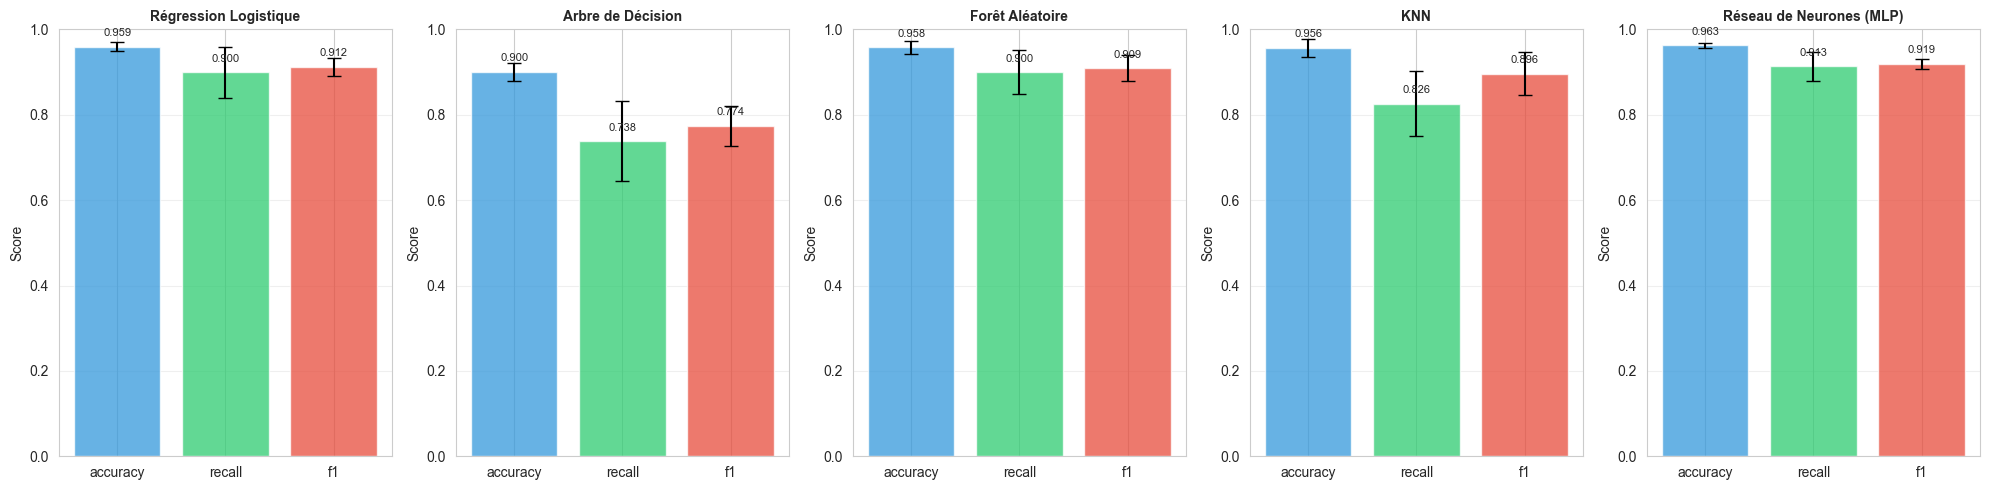


✓ CV corrigée: le prétraitement est appris à l'intérieur de chaque fold.
💡 Les scores CV sont désormais plus fiables pour estimer la généralisation.


In [19]:
from sklearn.base import clone
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

print("="*80)
print("ÉVALUATION PAR VALIDATION CROISÉE (5-fold) - SANS FUITE DE DONNÉES")
print("="*80)

# Modèles de référence (leurs hyperparamètres sont conservés)
models_for_cv = {
    'Régression Logistique': model_lr,
    'Arbre de Décision': model_dt,
    'Forêt Aléatoire': model_rf,
    'KNN': model_knn,
    'Réseau de Neurones (MLP)': model_mlp
}

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = {}

for model_name, model in models_for_cv.items():
    # Pipeline complet: chaque fold refit le prétraitement uniquement sur son sous-ensemble train
    cv_pipeline = Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('model', clone(model))
    ])

    scores = cross_validate(
        cv_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=scoring_metrics,
        return_train_score=True
    )
    cv_results[model_name] = scores

    print(f"\n✓ {model_name} - CV Scores:")
    for metric in scoring_metrics:
        values = scores[f'test_{metric}']
        print(f"  {metric:12} : {values.mean():.4f} (+/- {values.std():.4f})")

# Visualisation synthétique de la CV
plot_metrics = ['accuracy', 'recall', 'f1']
fig, axes = plt.subplots(1, len(models_for_cv), figsize=(4 * len(models_for_cv), 5))
if len(models_for_cv) == 1:
    axes = [axes]

for idx, (model_name, scores) in enumerate(cv_results.items()):
    ax = axes[idx]
    means = [scores[f'test_{m}'].mean() for m in plot_metrics]
    stds = [scores[f'test_{m}'].std() for m in plot_metrics]

    bars = ax.bar(plot_metrics, means, yerr=stds, capsize=5, alpha=0.75,
                  color=['#3498db', '#2ecc71', '#e74c3c'])
    ax.set_title(model_name, fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)

    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2., mean + 0.02,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ CV corrigée: le prétraitement est appris à l'intérieur de chaque fold.")
print("💡 Les scores CV sont désormais plus fiables pour estimer la généralisation.")

---
## 6. COMPARAISON DES MODÈLES
Grâce à la fonction d'évaluation commune, compare les performances des différents modèles en termes de précision, rappel, F1-score et AUC-ROC.

### 6.1 Tableau comparatif
Regroupe les métriques d'évaluation de tous les modèles dans un tableau commun pour une comparaison claire.

In [20]:
# Tableau comparatif des modèles retenus (base + KNN + MLP)
comparison_df = pd.DataFrame([
    results_lr,
    results_dt,
    results_rf,
    results_knn,
    results_mlp
])

comparison_display = comparison_df[[
    'Model', 'Train_Accuracy', 'Test_Accuracy', 'Overfit_Gap',
    'Precision', 'Recall', 'F1_Score', 'AUC_ROC'
]].round(4)

print("\n" + "="*120)
print("COMPARAISON DES MODÈLES")
print("="*120)
print(comparison_display.to_string(index=False))
print("="*120)


COMPARAISON DES MODÈLES
                   Model  Train_Accuracy  Test_Accuracy  Overfit_Gap  Precision  Recall  F1_Score  AUC_ROC
   Régression Logistique          0.9781         0.9500       0.0281     0.8537  0.9459    0.8974   0.9800
       Arbre de Décision          0.9562         0.8875       0.0688     0.7568  0.7568    0.7568   0.9107
         Forêt Aléatoire          0.9812         0.9125       0.0687     0.7674  0.8919    0.8250   0.9692
                     KNN          1.0000         0.9375       0.0625     0.9091  0.8108    0.8571   0.9567
Réseau de Neurones (MLP)          1.0000         0.9250       0.0750     0.8205  0.8649    0.8421   0.9809


### 6.2 Visualisation comparative des métriques
Utilisation de graphique pour une répresentation visuelle des performances.

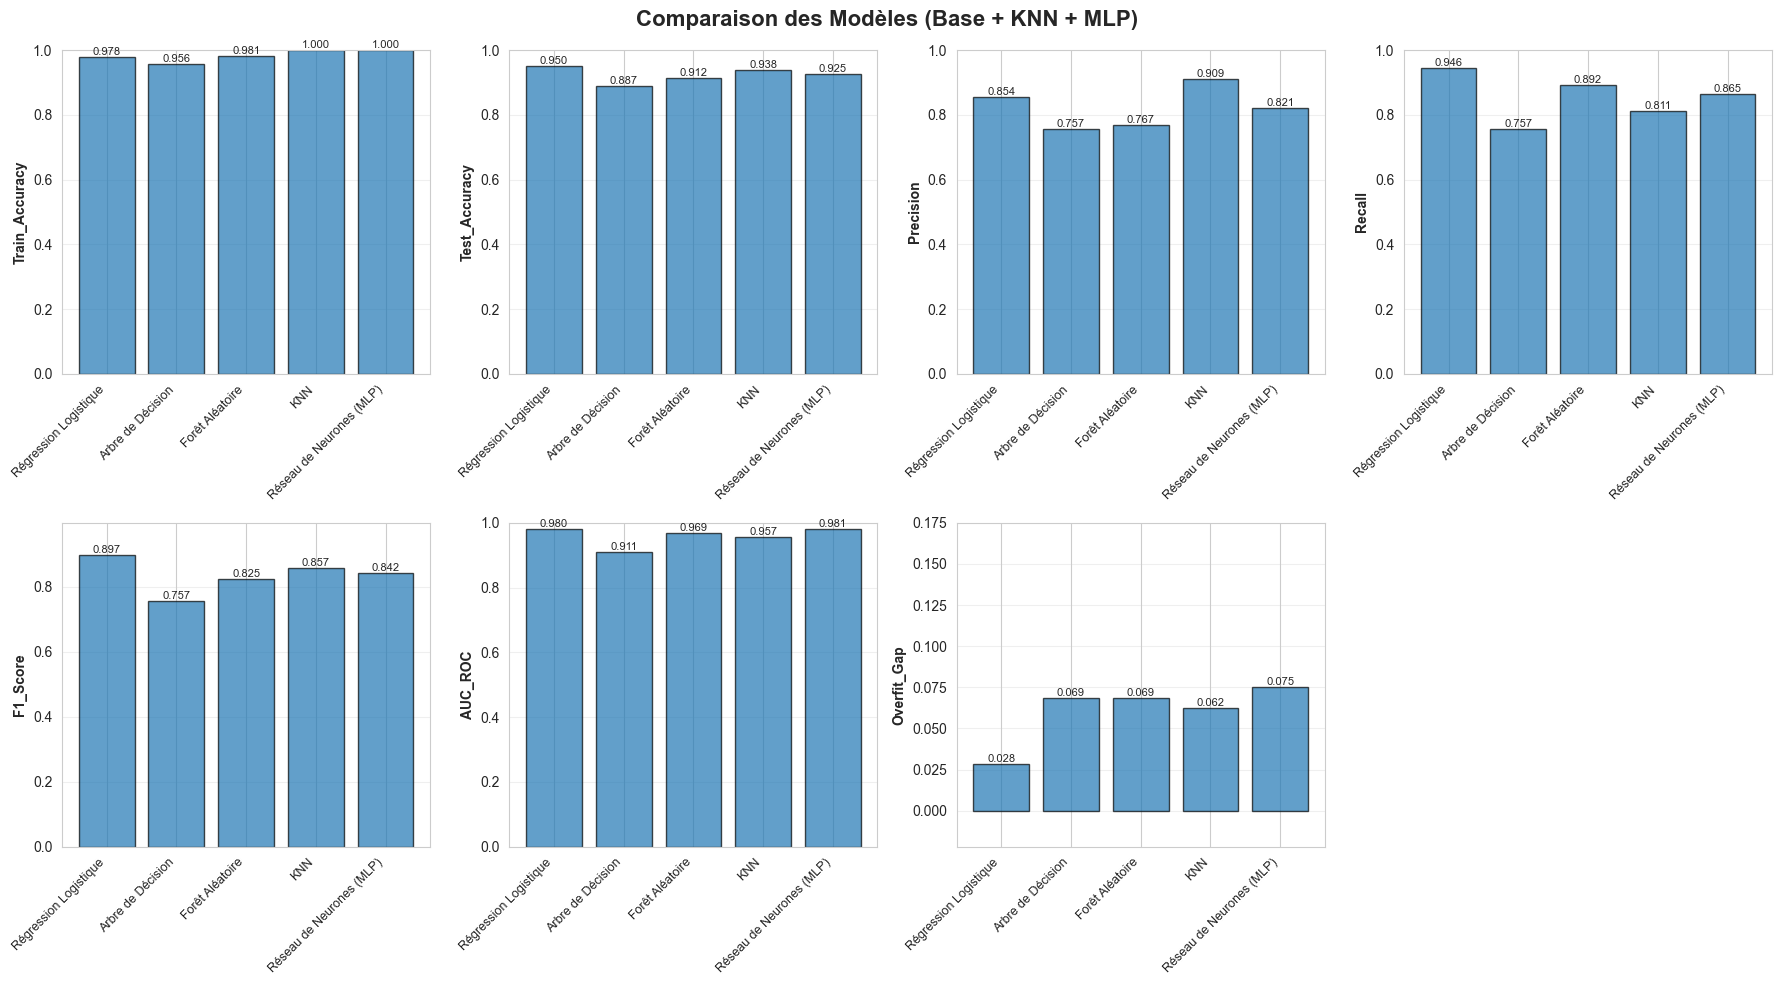


📊 INSIGHTS CLÉS:
✓ Meilleur F1-Score: Régression Logistique (0.8974)
✓ Meilleur AUC-ROC: Réseau de Neurones (MLP) (0.9809)
✓ Meilleur Recall: Régression Logistique (0.9459)


In [ ]:
# Visualisation comparative détaillée
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Comparaison des Modèles (Base + KNN + MLP)', fontsize=16, fontweight='bold')

models = comparison_df['Model'].tolist()
requested_metrics = ['Train_Accuracy', 'Test_Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC_ROC', 'Overfit_Gap']

metrics = [m for m in requested_metrics if m in comparison_df.columns]

for idx, metric in enumerate(metrics):
    ax = axes[idx // 4, idx % 4]
    values = comparison_df[metric].values
    bars = ax.bar(range(len(models)), values, alpha=0.7, edgecolor='black')

    ax.set_ylabel(metric, fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace('_', '\n') for m in models], rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([min(0, values.min() - 0.05), min(1, values.max() + 0.1)])

    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

for j in range(len(metrics), 8):
    axes[j // 4, j % 4].axis('off')

plt.tight_layout()
plt.show()

print("\nINSIGHTS CLÉS:")
best_f1_idx = comparison_df['F1_Score'].idxmax()
best_auc_idx = comparison_df['AUC_ROC'].idxmax()
print(f"✓ Meilleur F1-Score: {comparison_df.loc[best_f1_idx, 'Model']} ({comparison_df.loc[best_f1_idx, 'F1_Score']:.4f})")
print(f"✓ Meilleur AUC-ROC: {comparison_df.loc[best_auc_idx, 'Model']} ({comparison_df.loc[best_auc_idx, 'AUC_ROC']:.4f})")
print(f"✓ Meilleur Recall: {comparison_df.loc[comparison_df['Recall'].idxmax(), 'Model']} ({comparison_df['Recall'].max():.4f})")

## 7. ANALYSE ET INTERPRÉTATION CLINIQUE
Analyse et création d'un classement des modèles grâce aux donnéess du tableau comparatif.

### 7.1 Identification du Meilleur Modèle & Analyse Détaillée
Création du classement des meilleurs modèles.

In [ ]:


# Identifier le meilleur modèle selon plusieurs critères
print("\n" + "="*100)
print("SÉLECTION DU MEILLEUR MODÈLE")
print("="*100)

best_by_f1 = comparison_df.loc[comparison_df['F1_Score'].idxmax()]
best_by_auc = comparison_df.loc[comparison_df['AUC_ROC'].idxmax()]
best_by_recall = comparison_df.loc[comparison_df['Recall'].idxmax()]

print(f"\n Meilleur F1-Score:  {best_by_f1['Model']} → {best_by_f1['F1_Score']:.4f}")
print(f" Meilleur AUC-ROC:   {best_by_auc['Model']} → {best_by_auc['AUC_ROC']:.4f}")
print(f" Meilleur Recall:    {best_by_recall['Model']} → {best_by_recall['Recall']:.4f}")

# Analyser le meilleur modèle en détail
best_model_name = best_by_f1['Model']
best_model_row = best_by_f1

print(f"\n{'='*100}")
print(f" RAPPORT DÉTAILLÉ DU MEILLEUR MODÈLE: {best_model_name}")
print(f"{'='*100}")

print(f"""
✓ Performance en Généralisation:
  - Accuracy:      {best_model_row['Test_Accuracy']:.4f}
  - Précision:     {best_model_row['Precision']:.4f} (parmi les vrais positifs, combien sont corrects?)
  - Recall:        {best_model_row['Recall']:.4f} (parmi les malades, combien sont détectés?)
  - F1-Score:      {best_model_row['F1_Score']:.4f} (équilibre Precision-Recall)
  - AUC-ROC:       {best_model_row['AUC_ROC']:.4f} (performance globale)

✓ Diagnostic Surapprentissage:
  - Accuracy Train: {best_model_row['Train_Accuracy']:.4f}
  - Accuracy Test:  {best_model_row['Test_Accuracy']:.4f}
  - Gap:           {best_model_row['Overfit_Gap']:.4f} {'✓ Bon' if best_model_row['Overfit_Gap'] < 0.1 else '⚠️ Modéré' if best_model_row['Overfit_Gap'] < 0.15 else '🔴 Élevé'}
""")

print(f"{'='*100}")
print(" IMPLICATIONS CLINIQUES:")
print(f"{'='*100}")
print(f"""
1. SENSIBILITÉ (Recall) = {best_model_row['Recall']:.1%}
   → Parmi 100 patients malades, environ {int(best_model_row['Recall']*100)} seraient détectés.
   → Risque: {int((1-best_model_row['Recall'])*100)} patients pourraient être manqués → CRITIQUE

2. SPÉCIFICITÉ (1 - FPR) = aux alentours de {best_model_row['Precision']:.1%}
   → Parmi 100 patients sains, environ {int(best_model_row['Precision']*100)} seraient correctement identifiés.
   → Faux positifs possibles: {int((1-best_model_row['Precision'])*100)}/100

3. FIABILITÉ GLOBALE (AUC-ROC) = {best_model_row['AUC_ROC']:.4f}
   → Le modèle classe correctement {int(best_model_row['AUC_ROC']*100)}% des cas en moyenne.
   → Verdict: {'Excellent' if best_model_row['AUC_ROC'] > 0.9 else 'Très bon' if best_model_row['AUC_ROC'] > 0.8 else 'Bon' if best_model_row['AUC_ROC'] > 0.7 else 'Acceptable'}
""" )

print(f"{'='*100}") 


SÉLECTION DU MEILLEUR MODÈLE

🏆 Meilleur F1-Score:  Régression Logistique → 0.8974
🏆 Meilleur AUC-ROC:   Réseau de Neurones (MLP) → 0.9809
🏆 Meilleur Recall:    Régression Logistique → 0.9459

📋 RAPPORT DÉTAILLÉ DU MEILLEUR MODÈLE: Régression Logistique

✓ Performance en Généralisation:
  - Accuracy:      0.9500
  - Précision:     0.8537 (parmi les vrais positifs, combien sont corrects?)
  - Recall:        0.9459 (parmi les malades, combien sont détectés?)
  - F1-Score:      0.8974 (équilibre Precision-Recall)
  - AUC-ROC:       0.9800 (performance globale)

✓ Diagnostic Surapprentissage:
  - Accuracy Train: 0.9781
  - Accuracy Test:  0.9500
  - Gap:           0.0281 ✓ Bon

💊 IMPLICATIONS CLINIQUES:

1. SENSIBILITÉ (Recall) = 94.6%
   → Parmi 100 patients malades, environ 94 seraient détectés.
   → Risque: 5 patients pourraient être manqués → CRITIQUE

2. SPÉCIFICITÉ (1 - FPR) = aux alentours de 85.4%
   → Parmi 100 patients sains, environ 85 seraient correctement identifiés.
   → Fau

### 7.2 Synthèse visuelle (version allégée)
Systhèse visuelle globales des performances mise cote à côte pour une lecture finale rapide et efficace.

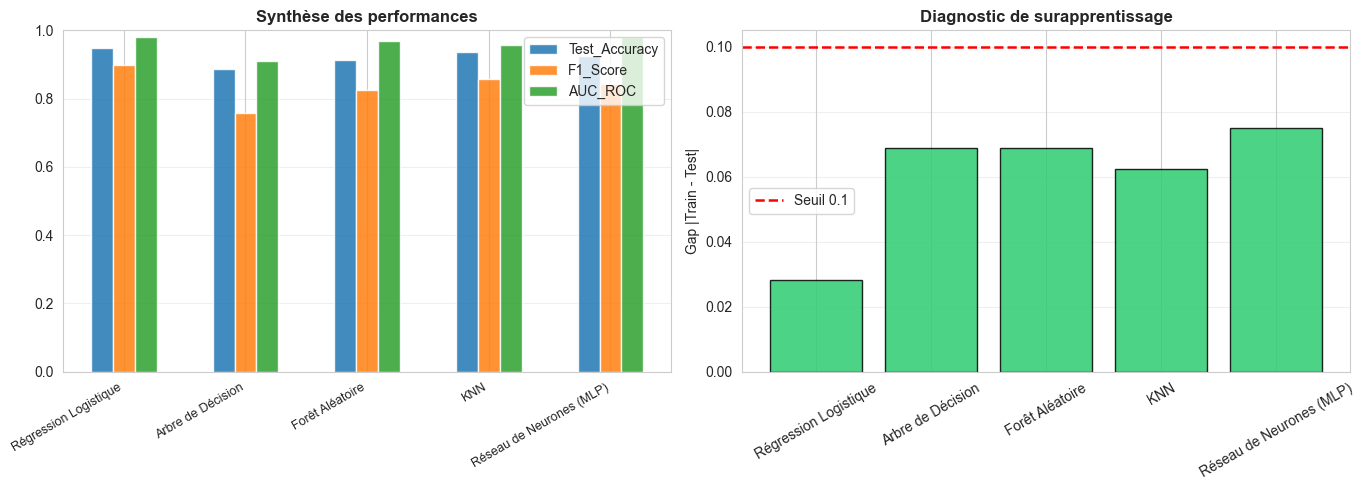

📌 Synthèse: détails graphiques déjà présentés en section 5.7 et section 6.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panneau 1: métriques clés (Test Accuracy, F1, AUC)
key_metrics = ['Test_Accuracy', 'F1_Score', 'AUC_ROC']
bar_width = 0.18
x = np.arange(len(comparison_df))

for i, metric in enumerate(key_metrics):
    axes[0].bar(
        x + i * bar_width,
        comparison_df[metric].values,
        width=bar_width,
        label=metric,
        alpha=0.85
    )

axes[0].set_title('Synthèse des performances', fontweight='bold')
axes[0].set_xticks(x + bar_width)
axes[0].set_xticklabels(comparison_df['Model'].tolist(), rotation=30, ha='right', fontsize=9)
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

# Panneau 2: gap de surapprentissage
colors = ['#2ecc71' if g < 0.1 else '#f39c12' if g < 0.15 else '#e74c3c' for g in comparison_df['Overfit_Gap']]
axes[1].bar(comparison_df['Model'], comparison_df['Overfit_Gap'], color=colors, edgecolor='black', alpha=0.85)
axes[1].axhline(0.1, linestyle='--', color='red', linewidth=1.8, label='Seuil 0.1')
axes[1].set_title('Diagnostic de surapprentissage', fontweight='bold')
axes[1].set_ylabel('Gap |Train - Test|')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print('📌 Synthèse: détails graphiques déjà présentés en section 5.7 et section 6.')

### 7.3 Courbes d'Apprentissage (Diagnostic Bias-Variance)
Visualisation des voubres d'apprentissage pour diagnostiquer les problèmes eventuels problèmes d'apprentissage (underfitting, overfitting).

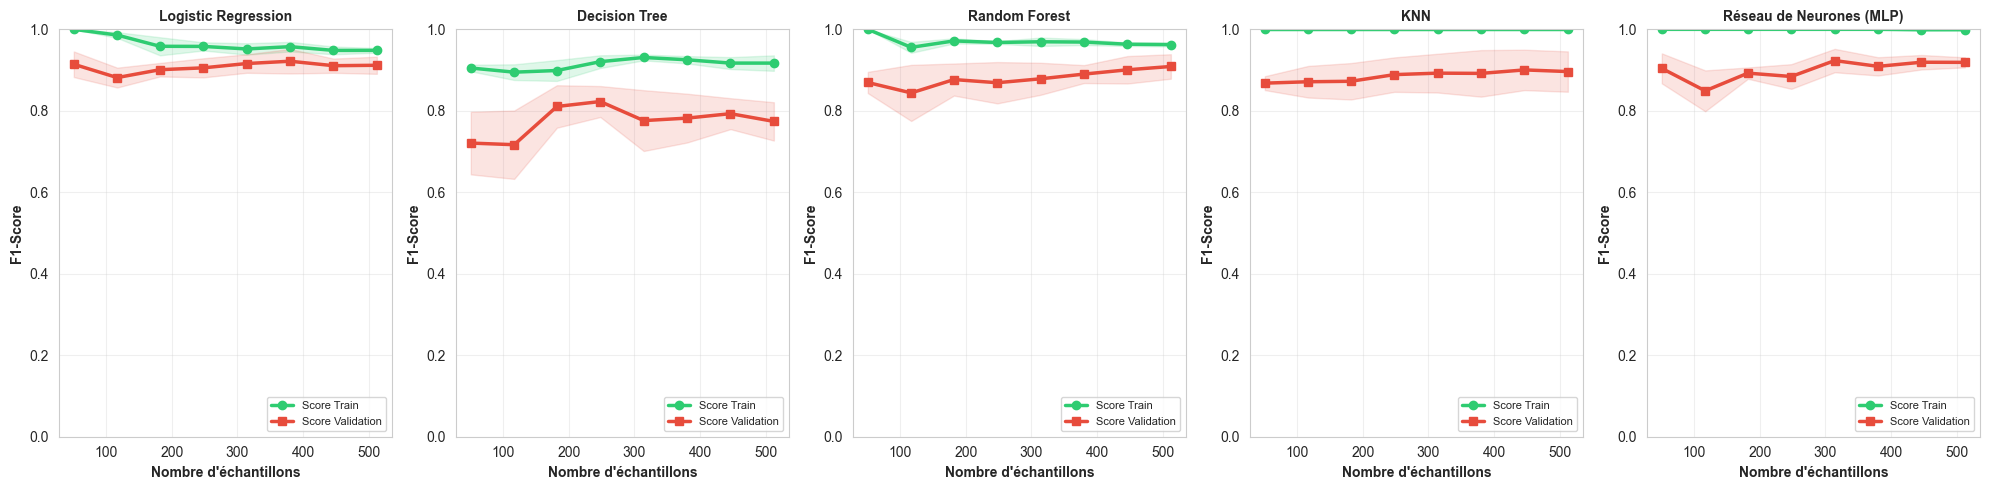

📈 DIAGNOSTIC BIAS-VARIANCE:
• Gap faible (train ≈ validation) = bon équilibre
• Gap large (train >> validation) = sur-apprentissage
• Train bas ET validation bas = sous-apprentissage
• Courbes qui convergent = quantité de données suffisante


In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, model_name, ax):
    """Trace la courbe d'apprentissage d'un modèle"""
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 8),
        scoring='f1', n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    ax.plot(train_sizes, train_mean, 'o-', label='Score Train', linewidth=2.5, color='#2ecc71', markersize=6)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2ecc71')

    ax.plot(train_sizes, val_mean, 's-', label='Score Validation', linewidth=2.5, color='#e74c3c', markersize=6)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e74c3c')

    ax.set_xlabel('Nombre d\'échantillons', fontweight='bold', fontsize=10)
    ax.set_ylabel('F1-Score', fontweight='bold', fontsize=10)
    ax.set_title(model_name, fontweight='bold', fontsize=10)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1])

learning_models = [
    (model_lr, X_train_transformed, y_train, 'Logistic Regression'),
    (model_dt, X_train_transformed, y_train, 'Decision Tree'),
    (model_rf, X_train_transformed, y_train, 'Random Forest'),
    (model_knn, X_train_transformed, y_train, 'KNN'),
    (model_mlp, X_train_transformed, y_train, 'Réseau de Neurones (MLP)')
]

fig, axes = plt.subplots(1, len(learning_models), figsize=(4 * len(learning_models), 5))
if len(learning_models) == 1:
    axes = [axes]

for ax, (model, X_data, y_data, label) in zip(axes, learning_models):
    plot_learning_curve(model, X_data, y_data, label, ax)

plt.tight_layout()
plt.show()

print(" DIAGNOSTIC BIAS-VARIANCE:")
print("• Gap faible (train ≈ validation) = bon équilibre")
print("• Gap large (train >> validation) = sur-apprentissage")
print("• Train bas ET validation bas = sous-apprentissage")
print("• Courbes qui convergent = quantité de données suffisante")

---
## 8. ANALYSE CRITIQUE ET RÉSULTATS
Analyse des meilleurs et pire modèles en se basant sur les métriques bonne comme mauvaises.

### 8.1 Analyse complète

In [ ]:
print("ANALYSE CLINIQUE ET D'INTERPRÉTATION")
print("="*80)

print("\n1. DÉSÉQUILIBRE DES CLASSES:")
class_0_pct = (y==0).sum()/len(y)*100
class_1_pct = (y==1).sum()/len(y)*100
print(f"   - Absence de pathologie (0): {class_0_pct:.1f}%")
print(f"   - Présence de pathologie (1): {class_1_pct:.1f}%")
print(f"   - Imbalancement: {abs(class_0_pct - class_1_pct):.1f}%")
if abs(class_0_pct - class_1_pct) > 20:
    print(f"     DÉSÉQUILIBRE SIGNIFICATIF - F1-score plus pertinent qu'Accuracy")

print("\n2. MEILLEUR MODÈLE:")
best_idx = comparison_df['F1_Score'].idxmax()
best_model_name = comparison_df.iloc[best_idx]['Model']
print(f"   {best_model_name}")

print("\n3. SURAPPRENTISSAGE:")
for idx, row in comparison_df.iterrows():
    gap = row['Overfit_Gap']
    status = "*  ÉLEVÉ" if gap > 0.1 else "✓ Acceptable"
    print(f"   {row['Model']}: {gap:.4f} {status}")

print("\n" + "="*80)

ANALYSE CLINIQUE ET D'INTERPRÉTATION

1. DÉSÉQUILIBRE DES CLASSES:
   - Absence de pathologie (0): 76.8%
   - Présence de pathologie (1): 23.2%
   - Imbalancement: 53.5%
   ⚠️  DÉSÉQUILIBRE SIGNIFICATIF - F1-score plus pertinent qu'Accuracy

2. MEILLEUR MODÈLE:
   Régression Logistique

3. SURAPPRENTISSAGE:
   Régression Logistique: 0.0281 ✓ Acceptable
   Arbre de Décision: 0.0688 ✓ Acceptable
   Forêt Aléatoire: 0.0687 ✓ Acceptable
   KNN: 0.0625 ✓ Acceptable
   Réseau de Neurones (MLP): 0.0750 ✓ Acceptable



### 8.2 Rapport du meilleur modèle
Analyse détaillée du meilleur modèle, en mettant en avant ses points forts et ses faiblesses.

In [ ]:
best_idx = comparison_df['F1_Score'].idxmax()
best_result = comparison_df.loc[best_idx]
best_model_name = best_result['Model']

model_results_map = {
    results_lr['Model']: results_lr,
    results_dt['Model']: results_dt,
    results_rf['Model']: results_rf,
    results_knn['Model']: results_knn,
    results_mlp['Model']: results_mlp
}

print(f"\n MEILLEUR MODÈLE: {best_model_name}")
print("="*80)

y_best_pred = model_results_map[best_model_name]['y_test_pred']
print("\nRAPPORT DE CLASSIFICATION:")
print(classification_report(
    y_test, y_best_pred,
    target_names=['Pas de pathologie', 'Pathologie présente']
))

print("SYNTHÈSE AUTOMATIQUE:")
print(f"- F1-score:  {best_result['F1_Score']:.4f}")
print(f"- Recall:    {best_result['Recall']:.4f} (prioritaire en dépistage)")
print(f"- Precision: {best_result['Precision']:.4f}")
print(f"- AUC-ROC:   {best_result['AUC_ROC']:.4f}")
print(f"- Overfit gap: {best_result['Overfit_Gap']:.4f}")

if best_result['Recall'] >= 0.9:
    print("- Interprétation: très bonne détection de la classe positive (peu de faux négatifs).")
elif best_result['Recall'] >= 0.8:
    print("- Interprétation: détection correcte de la classe positive, améliorable.")
else:
    print("- Interprétation: rappel insuffisant pour un contexte clinique de dépistage.")


🏆 MEILLEUR MODÈLE: Régression Logistique

RAPPORT DE CLASSIFICATION:
                     precision    recall  f1-score   support

  Pas de pathologie       0.98      0.95      0.97       123
Pathologie présente       0.85      0.95      0.90        37

           accuracy                           0.95       160
          macro avg       0.92      0.95      0.93       160
       weighted avg       0.95      0.95      0.95       160

SYNTHÈSE AUTOMATIQUE:
- F1-score:  0.8974
- Recall:    0.9459 (prioritaire en dépistage)
- Precision: 0.8537
- AUC-ROC:   0.9800
- Overfit gap: 0.0281
- Interprétation: très bonne détection de la classe positive (peu de faux négatifs).


---
## 9. CONCLUSIONS

### 9.1 Résumé et recommandations

Le modèle le plus pertinent au regard du contexte clinique est la **Régression Logistique**.

Résultats test (exécution du notebook):
- Accuracy: **0.950**
- Precision: **0.854**
- Recall (classe positive): **0.946**
- F1-score: **0.897**
- AUC-ROC: **0.980**
- Overfit gap: **0.028** (faible, bonne généralisation)

Comparaison rapide:
- KNN donne une meilleure précision (**0.909**) mais un rappel plus faible (**0.811**), donc plus de malades manqués.
- Pour un usage de dépistage, la priorité est souvent de **maximiser le rappel** de la classe positive.

Recommandation pratique: conserver la Régression Logistique comme modèle de base et ajuster le seuil de décision selon le coût clinique des faux négatifs.

### 9.2 Réponses aux questions cliniques du sujet

**1) Comportement face à la classe positive (présence de pathologie)**
- Le modèle détecte bien les patients positifs: recall = **0.946**.
- Cela signifie qu'environ **95%** des patients réellement malades sont identifiés.

**Conséquences cliniques d’un faux négatif**
- Un faux négatif correspond à un patient malade classé sain.
- Risques: retard diagnostique, absence de prise en charge, aggravation possible de la pathologie.
- En pratique médicale, ce type d’erreur est souvent le plus critique.

**2) Comportement face à la classe négative (absence de pathologie)**
- La précision de **0.854** indique qu'une bonne part des prédictions positives sont correctes, mais il reste des faux positifs.
- La classe négative est globalement bien gérée, mais avec un compromis volontaire en faveur du rappel des positifs.

**Conséquences d’un faux positif pour le patient**
- Anxiété inutile, examens complémentaires, coût supplémentaire et potentielle surcharge du système de soins.
- Ces conséquences sont réelles, mais en dépistage elles sont souvent jugées moins graves qu’un faux négatif.

**3) Équilibre du jeu de données et impact**
- Le dataset est **déséquilibré**:
  - Classe 0 (No): **614 / 800 = 76.75%**
  - Classe 1 (Yes): **186 / 800 = 23.25%**
- Ce déséquilibre rend l’accuracy seule insuffisante.
- D’où le choix de métriques adaptées: **Recall, Precision, F1-score, AUC-ROC**.
- Il justifie aussi l’usage de modèles/paramètres robustes au déséquilibre (ex. pondération de classes pour certains modèles).

### 9.3 Limites et améliorations futures

**Limites de l’approche actuelle**
- Données synthétiques: transfert vers données réelles limité.
- Validation encore centrée sur un seul split train/test (même si CV effectuée).
- Pas d’optimisation systématique du seuil de décision selon coût clinique.
- Interprétabilité perfectible pour certains modèles (MLP/KNN).

**Ce qui serait fait avec plus de temps/données**
- Validation externe sur un jeu indépendant (idéalement multicentrique).
- Optimisation d’hyperparamètres plus poussée (GridSearch/RandomSearch + CV stratifiée).
- Calibration des probabilités (Platt/Isotonic) pour un usage clinique.
- Optimisation du seuil pour minimiser explicitement les faux négatifs.
- Ajout d’analyses d’explicabilité (SHAP, permutation importance) et d’équité des performances par sous-groupes.